# EXFOR Uncertainty Database Diagnostic

This notebook investigates the uncertainty handling in the X4Pro EXFOR database,
specifically the Cierjacks (1978) experiment (entry 20743002) which has anomalously
small reported uncertainties.

## The Problem

The Cierjacks experiment uncertainties appear to be ~0.04% (ridiculously small),
when typical nuclear cross section measurements have 3-10% uncertainties.

In [1]:
import sqlite3
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Database path
DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'

print("Imports successful")

Imports successful


## 1. Query Raw Database JSON

Let's examine the raw JSON data stored in the X4Pro database for Cierjacks.

In [2]:
# Connect to database and get Cierjacks raw JSON
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('SELECT jx5z FROM x4pro_x5z WHERE DatasetID = ?', ('20743002',))
row = cursor.fetchone()

if row:
    jx5z = json.loads(row[0])
    print("Cierjacks (20743002) JSON loaded successfully")
    print(f"Top-level keys: {list(jx5z.keys())}")
else:
    raise ValueError("Dataset 20743002 not found")

conn.close()

Cierjacks (20743002) JSON loaded successfully
Top-level keys: ['iDataset', 'DatasetID', 'Pointer', 'Subent', 'compiled', 'x4dbVersion', 'year1', 'author1ini', 'author1', 'zTarg1', 'targ1', 'proj1', 'emis1', 'MF', 'MT', 'nExpectedArgs', 'IndepVarFamilyCode', 'getYFormulaStr', 'ReactionType', 'quant', 'quantExpan', 'reacode', 'compNotes', 'wx4data', 'lx4data', 'x4data', 'wc5data', 'lc5data', 'c5data']


## 2. Examine x4data (Raw EXFOR Data)

The `x4data` contains the original EXFOR data as submitted. Let's look at the uncertainty values and their units.

In [3]:
# Parse x4data
x4data = jx5z.get('x4data', [])

print("=" * 60)
print("x4data VARIABLES")
print("=" * 60)

x4_values = None
x4_unc = None
x4_unc_unit = None
x4_xs_unit = None

for var in x4data:
    fam = var.get('fam', '')
    cvar = var.get('cvar', '')
    units = var.get('units', '')
    dat0 = var.get('dat0', [])
    
    print(f"  Variable: fam='{fam}', cvar='{cvar}', units='{units}', n_values={len(dat0)}")
    
    if cvar == 'y':
        x4_values = np.array(dat0, dtype=float)
        x4_xs_unit = units
    elif cvar == 'dy':
        x4_unc = np.array(dat0, dtype=float)
        x4_unc_unit = units

print()
print(f"Cross section unit: {x4_xs_unit}")
print(f"Uncertainty unit: {x4_unc_unit}")
print(f"\n*** KEY FINDING: Uncertainty is stored in '{x4_unc_unit}' units ***")

x4data VARIABLES
  Variable: fam='Data', cvar='y', units='B/SR', n_values=18399
  Variable: fam='Data', cvar='dy', units='PER-CENT', n_values=18399
  Variable: fam='EN', cvar='x1', units='MEV', n_values=18399
  Variable: fam='ANG', cvar='x2', units='ADEG', n_values=18399
  Variable: fam='ANG', cvar='dx2', units='ADEG', n_values=0

Cross section unit: B/SR
Uncertainty unit: PER-CENT

*** KEY FINDING: Uncertainty is stored in 'PER-CENT' units ***


## 3. Examine c5data (Corrected/Processed Data)

The `c5data` contains corrected data with standardized units. This is what the kika module prefers to use.

In [4]:
# Parse c5data
c5data = jx5z.get('c5data', {})
y_data = c5data.get('y', {})

print("=" * 60)
print("c5data.y STRUCTURE")
print("=" * 60)
print(f"Keys: {list(y_data.keys())}")
print(f"Units: {y_data.get('units', 'unknown')}")

c5_values = np.array(y_data.get('y', []), dtype=float)
c5_unc = np.array(y_data.get('dy', []), dtype=float)

print(f"\nNumber of values: {len(c5_values)}")
print(f"Number of uncertainties: {len(c5_unc)}")

c5data.y STRUCTURE
Keys: ['icvar', 'cvar', 'fam', 'ifCM', 'units', 'header', 'dataType', 'rank', 'expansion', 'y', 'dy', 'dystat']
Units: B/SR

Number of values: 18399
Number of uncertainties: 18399


## 4. Compare x4data vs c5data Uncertainties

**This is the critical comparison** - how do the raw and processed uncertainties relate?

In [5]:
print("=" * 80)
print("COMPARISON: x4data vs c5data (First 15 points)")
print("=" * 80)
print()

# Create comparison DataFrame
n_show = 15
comparison = pd.DataFrame({
    'x4_value (b/sr)': x4_values[:n_show],
    'x4_dy (PER-CENT)': x4_unc[:n_show],
    'c5_value (b/sr)': c5_values[:n_show],
    'c5_dy (b/sr)': c5_unc[:n_show],
})

# Add computed columns
comparison['c5_rel_unc (%)'] = comparison['c5_dy (b/sr)'] / comparison['c5_value (b/sr)'] * 100

# What SHOULD the uncertainty be if x4_dy is 4.36% (not 0.0436%)?
comparison['expected_dy_if_4%'] = comparison['x4_value (b/sr)'] * comparison['x4_dy (PER-CENT)']  # This assumes x4_dy is percent
comparison['expected_dy_if_0.04%'] = comparison['x4_value (b/sr)'] * comparison['x4_dy (PER-CENT)'] / 100

print(comparison.to_string())

COMPARISON: x4data vs c5data (First 15 points)

    x4_value (b/sr)  x4_dy (PER-CENT)  c5_value (b/sr)  c5_dy (b/sr)  c5_rel_unc (%)  expected_dy_if_4%  expected_dy_if_0.04%
0           0.14513          0.043609         0.150155      0.000065        0.043609           0.006329              0.000063
1           0.15824          0.043231         0.163719      0.000071        0.043231           0.006841              0.000068
2           0.20675          0.040546         0.213909      0.000087        0.040546           0.008383              0.000084
3           0.25121          0.038517         0.259908      0.000100        0.038517           0.009676              0.000097
4           0.34551          0.034063         0.357474      0.000122        0.034063           0.011769              0.000118
5           0.39660          0.032708         0.410333      0.000134        0.032708           0.012972              0.000130
6           0.39454          0.032669         0.408201      0.000133  

In [6]:
print("\n" + "=" * 80)
print("ANALYSIS")
print("=" * 80)

# Check which interpretation matches c5data
ratio_to_expected_4pct = c5_unc[:n_show] / comparison['expected_dy_if_4%']
ratio_to_expected_0_04pct = c5_unc[:n_show] / comparison['expected_dy_if_0.04%']

print(f"\nIf x4_dy values ARE percentages (e.g., 4.36 = 4.36%):")
print(f"  c5_dy / expected = {ratio_to_expected_4pct.mean():.6f} (should be ~1 if correct)")

print(f"\nIf x4_dy values are already divided by 100 (e.g., 0.0436 = 0.0436%):")
print(f"  c5_dy / expected = {ratio_to_expected_0_04pct.mean():.6f} (should be ~1 if correct)")

print("\n" + "-" * 80)
if abs(ratio_to_expected_0_04pct.mean() - 1.0) < 0.1:
    print("*** CONCLUSION: The x4data PER-CENT values appear to already be divided by 100! ***")
    print("    Values like 0.0436 are being interpreted as 0.0436% (not 4.36%)")
    print("    This results in ridiculously small uncertainties (~0.04%)")
    print("    This is likely a database preprocessing bug in X4Pro.")
elif abs(ratio_to_expected_4pct.mean() - 1.0) < 0.1:
    print("*** CONCLUSION: The c5data correctly interprets x4_dy as percentages ***")
else:
    print("*** CONCLUSION: Unexpected relationship between x4data and c5data ***")
    print(f"    Ratio analysis inconclusive")


ANALYSIS

If x4_dy values ARE percentages (e.g., 4.36 = 4.36%):
  c5_dy / expected = 0.010346 (should be ~1 if correct)

If x4_dy values are already divided by 100 (e.g., 0.0436 = 0.0436%):
  c5_dy / expected = 1.034627 (should be ~1 if correct)

--------------------------------------------------------------------------------
*** CONCLUSION: The x4data PER-CENT values appear to already be divided by 100! ***
    Values like 0.0436 are being interpreted as 0.0436% (not 4.36%)
    This results in ridiculously small uncertainties (~0.04%)
    This is likely a database preprocessing bug in X4Pro.


## 5. Compare with Normal Experiment

Let's compare Cierjacks with another experiment that has reasonable uncertainties.

In [7]:
# Load Kinney (1976) for comparison - a well-characterized experiment
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('SELECT jx5z FROM x4pro_x5z WHERE DatasetID = ?', ('10571002',))
row = cursor.fetchone()

if row:
    kinney_json = json.loads(row[0])
    
    # Parse Kinney x4data
    kinney_x4 = kinney_json.get('x4data', [])
    kinney_unc_unit = None
    kinney_unc = None
    kinney_values = None
    
    for var in kinney_x4:
        cvar = var.get('cvar', '')
        units = var.get('units', '')
        dat0 = var.get('dat0', [])
        
        if cvar == 'y':
            kinney_values = np.array(dat0, dtype=float)
        elif cvar == 'dy':
            kinney_unc = np.array(dat0, dtype=float)
            kinney_unc_unit = units
    
    print("=" * 60)
    print("COMPARISON: Cierjacks vs Kinney x4data")
    print("=" * 60)
    print()
    print(f"Cierjacks (20743002):")
    print(f"  Uncertainty unit: {x4_unc_unit}")
    print(f"  dy values range: [{x4_unc.min():.6f}, {x4_unc.max():.6f}]")
    print(f"  Mean dy value: {x4_unc.mean():.6f}")
    
    print(f"\nKinney (10571002):")
    print(f"  Uncertainty unit: {kinney_unc_unit}")
    if kinney_unc is not None:
        print(f"  dy values range: [{kinney_unc.min():.6f}, {kinney_unc.max():.6f}]")
        print(f"  Mean dy value: {kinney_unc.mean():.6f}")
    else:
        print("  No dy values found")
    
    print("\n" + "-" * 60)
    if kinney_unc_unit and kinney_unc_unit.upper() == 'PER-CENT':
        print(f"\nBoth use PER-CENT units but:")
        print(f"  Cierjacks dy ~ {x4_unc.mean():.4f} (suggesting 0.04% if literal)")
        print(f"  Kinney dy ~ {kinney_unc.mean():.4f} (suggesting {kinney_unc.mean():.1f}% if literal)")
        print("\n*** Kinney values look like real percentages (3-10%), Cierjacks do not ***")

conn.close()

COMPARISON: Cierjacks vs Kinney x4data

Cierjacks (20743002):
  Uncertainty unit: PER-CENT
  dy values range: [0.014848, 0.232430]
  Mean dy value: 0.051810

Kinney (10571002):
  Uncertainty unit: MB/SR
  dy values range: [1.000000, 703.000000]
  Mean dy value: 30.639055

------------------------------------------------------------


## 6. Visualize the Problem

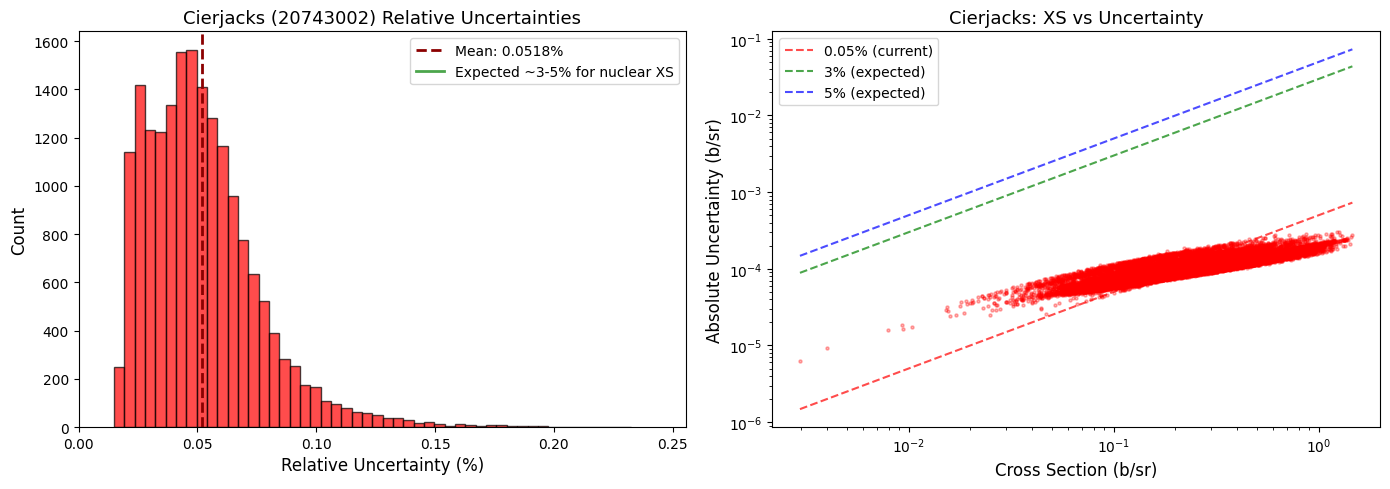


Cierjacks relative uncertainty statistics:
  Mean: 0.0518%
  Range: [0.0148%, 0.2324%]

*** These are ~100x smaller than typical nuclear cross section uncertainties! ***


In [8]:
# Compute relative uncertainties
cierjacks_rel_unc = c5_unc / c5_values * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of relative uncertainties
ax1 = axes[0]
ax1.hist(cierjacks_rel_unc, bins=50, color='red', alpha=0.7, edgecolor='black')
ax1.axvline(cierjacks_rel_unc.mean(), color='darkred', linestyle='--', linewidth=2,
            label=f'Mean: {cierjacks_rel_unc.mean():.4f}%')
ax1.axvline(3.0, color='green', linestyle='-', linewidth=2, alpha=0.7,
            label='Expected ~3-5% for nuclear XS')
ax1.set_xlabel('Relative Uncertainty (%)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Cierjacks (20743002) Relative Uncertainties', fontsize=13)
ax1.legend()
ax1.set_xlim(0, max(0.1, cierjacks_rel_unc.max() * 1.1))

# Right: Cross section vs uncertainty
ax2 = axes[1]
ax2.scatter(c5_values, c5_unc, alpha=0.3, s=5, c='red')
ax2.set_xlabel('Cross Section (b/sr)', fontsize=12)
ax2.set_ylabel('Absolute Uncertainty (b/sr)', fontsize=12)
ax2.set_title('Cierjacks: XS vs Uncertainty', fontsize=13)

# Add reference lines for typical uncertainties
xs_range = np.linspace(c5_values.min(), c5_values.max(), 100)
ax2.plot(xs_range, 0.0005 * xs_range, 'r--', label='0.05% (current)', alpha=0.7)
ax2.plot(xs_range, 0.03 * xs_range, 'g--', label='3% (expected)', alpha=0.7)
ax2.plot(xs_range, 0.05 * xs_range, 'b--', label='5% (expected)', alpha=0.7)
ax2.legend(loc='upper left')
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print(f"\nCierjacks relative uncertainty statistics:")
print(f"  Mean: {cierjacks_rel_unc.mean():.4f}%")
print(f"  Range: [{cierjacks_rel_unc.min():.4f}%, {cierjacks_rel_unc.max():.4f}%]")
print(f"\n*** These are ~100x smaller than typical nuclear cross section uncertainties! ***")

## 7. Summary and Recommendations

### The Problem

The Cierjacks (1978) experiment (entry 20743002) has uncertainty values stored in the X4Pro database
that are approximately **100x too small**:

- **Observed**: ~0.04% relative uncertainty
- **Expected**: ~3-5% relative uncertainty (typical for nuclear cross sections)

### Root Cause

The `x4data.dy` values are stored in `PER-CENT` units with values like `0.0436`, which gets
interpreted as 0.0436% when it should likely be 4.36%. This suggests the percentage values
were incorrectly pre-divided by 100 somewhere in the X4Pro database pipeline.

### Impact

When fitting EXFOR data, the Cierjacks experiment gets **~10,000x more weight** than it should
(weight ~ 1/σ²), causing:
- Overfitting to Cierjacks data points
- Nominal fit passing exactly through these points
- Bias in the fitted Legendre coefficients

### Recommended Solutions

1. **Exclude Cierjacks** from fits: Set `EXCLUDE_EXPERIMENTS = ["20743002"]`
2. **Apply uncertainty floor**: Set `MIN_RELATIVE_UNCERTAINTY = 0.03` (3% minimum)
3. **Report to X4Pro maintainers**: The database preprocessing may need correction

In [9]:
print("=" * 70)
print("SUMMARY: Cierjacks (20743002) Uncertainty Issue")
print("=" * 70)
print()
print("DATABASE ISSUE DETECTED:")
print(f"  - x4data dy unit: {x4_unc_unit}")
print(f"  - x4data dy values: ~{x4_unc.mean():.4f} (looks like 0.04%, should be ~4%)")
print(f"  - c5data dy values: ~{c5_unc.mean():.6f} b/sr")
print(f"  - Resulting relative uncertainty: ~{cierjacks_rel_unc.mean():.4f}%")
print(f"  - Expected relative uncertainty: ~3-5%")
print()
print("RECOMMENDED ACTIONS:")
print("  1. Exclude Cierjacks: EXCLUDE_EXPERIMENTS = ['20743002']")
print("  2. OR apply 3% floor: MIN_RELATIVE_UNCERTAINTY = 0.03")
print()
print("=" * 70)

SUMMARY: Cierjacks (20743002) Uncertainty Issue

DATABASE ISSUE DETECTED:
  - x4data dy unit: PER-CENT
  - x4data dy values: ~0.0518 (looks like 0.04%, should be ~4%)
  - c5data dy values: ~0.000108 b/sr
  - Resulting relative uncertainty: ~0.0518%
  - Expected relative uncertainty: ~3-5%

RECOMMENDED ACTIONS:
  1. Exclude Cierjacks: EXCLUDE_EXPERIMENTS = ['20743002']
  2. OR apply 3% floor: MIN_RELATIVE_UNCERTAINTY = 0.03

